**Objectives:**

By the end of this lab, you will be able to:

- Understand the core components of a Transformer architecture.
- Implement a multi-head self-attention mechanism from scratch.
- Train and evaluate a Transformer for time series prediction.
- Handle preprocessing and scaling for time series data effectively.


## What is a Transformer?

The Transformer architecture was introduced in the paper *"Attention Is All You Need"*. It revolutionized natural language processing by using attention mechanisms instead of recurrence.

### Key Components:
- **Input Embedding:** Converts input tokens (or time steps) into vectors.
- **Positional Encoding:** Injects information about the position of input tokens.
- **Multi-Head Self-Attention:** Allows the model to focus on different parts of the input sequence.
- **Feedforward Layers:** Process the attended information.
- **Layer Normalization & Residual Connections:** Stabilize and speed up training.

> Transformers are now widely used not only in NLP but also in time series forecasting, image recognition, and more.

In [1]:
%pip install tensorflow pyarrow
%pip install pandas
%pip install scikit-learn
%pip install matplotlib
%pip install requests


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import requests
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Layer, Dense, LayerNormalization, Dropout

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

Setup the Environment to generate synthetic stock price data

In [3]:
import numpy as np
import pandas as pd

# Create a synthetic stock price dataset
np.random.seed(42)
data_length = 2000  # Adjust data length as needed
trend = np.linspace(100, 200, data_length)
noise = np.random.normal(0, 2, data_length)
synthetic_data = trend + noise

# Create a DataFrame and save as 'stock_prices.csv'
data = pd.DataFrame(synthetic_data, columns=['Close'])
data.to_csv('stock_prices.csv', index=False)
print("Synthetic stock_prices.csv created and loaded.")

Synthetic stock_prices.csv created and loaded.


In [4]:
# Load the dataset
data = pd.read_csv('stock_prices.csv')
data = data[['Close']].values

# Normalise the data
scalar = MinMaxScaler(feature_range=(0, 1))
data = scalar.fit_transform(data)

# Prepare the data for training
def create_dataset(data, time_step=1):
  X, Y =[],[]

  for i in range(len(data)-time_step-1):
    a = data[i:(i+time_step), 0]
    y = data[i+time_step, 0]
    X.append(a)
    Y.append(y)
  return np.array(X), np.array(Y)

time_step = 100
X, Y = create_dataset(data, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (1899, 100, 1)
Shape of Y: (1899,)


In [5]:
class MultiHeadSelfAttention(Layer):

    def __init__(self, embed_dim, num_heads=8):
        super(MultiHeadSelfAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.projection_dim = embed_dim // num_heads
        self.query_dense = Dense(embed_dim)
        self.key_dense = Dense(embed_dim)
        self.value_dense = Dense(embed_dim)
        self.combine_heads = Dense(embed_dim)


    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        output = tf.matmul(weights, value)
        return output, weights

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)
        attention, _ = self.attention(query, key, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        output = self.combine_heads(concat_attention)
        return output


In [6]:
class TransformerBlock(Layer):

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])

        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)


    def call(self, inputs, training):
        attn_output = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

In [7]:
class EncoderLayer(Layer):

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(EncoderLayer, self).__init__()
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])

        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)



    def call(self, inputs, training):
        attn_output = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, LayerNormalization, Dropout

class MultiHeadSelfAttention(Layer):
    def __init__(self, embed_dim, num_heads=8):
        super(MultiHeadSelfAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.projection_dim = embed_dim // num_heads
        self.query_dense = Dense(embed_dim)
        self.key_dense = Dense(embed_dim)
        self.value_dense = Dense(embed_dim)
        self.combine_heads = Dense(embed_dim)


    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        output = tf.matmul(weights, value)
        return output, weights


    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])


    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)
        attention, _ = self.attention(query, key, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        output = self.combine_heads(concat_attention)
        return output

class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])

        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)


    def call(self, inputs, training):
        attn_output = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

class TransformerEncoder(Layer):
    def __init__(self, num_layers, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerEncoder, self).__init__()
        self.num_layers = num_layers
        self.embed_dim = embed_dim
        self.enc_layers = [TransformerBlock(embed_dim, num_heads, ff_dim, rate) for _ in range(num_layers)]
        self.dropout = Dropout(rate)

    def call(self, inputs, training=False):
        x = inputs
        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training)
        return x

# Example usage
embed_dim = 128
num_heads = 8
ff_dim = 512
num_layers = 4

transformer_encoder = TransformerEncoder(num_layers, embed_dim, num_heads, ff_dim)
inputs = tf.random.uniform((1, 100, embed_dim))
outputs = transformer_encoder(inputs, training=False)  # Use keyword argument for 'training'
print(outputs.shape)  # Should print (1, 100, 128)

(1, 100, 128)


In [9]:
# Define the necessary parameters

embed_dim = 128
num_heads = 8
ff_dim = 512
num_layers = 4

# Define the Transformer Encoder
transformer_encoder = TransformerEncoder(num_layers, embed_dim, num_heads, ff_dim)

# Build the model
input_shape = (X.shape[1], X.shape[2])
inputs = tf.keras.Input(shape=input_shape)

# Project the inputs to the embed_dim
x = tf.keras.layers.Dense(embed_dim)(inputs)
encoder_outputs = transformer_encoder(x)
flatten = tf.keras.layers.Flatten()(encoder_outputs)
outputs = tf.keras.layers.Dense(1)(flatten)
model = tf.keras.Model(inputs, outputs)

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Summary of the model
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 100, 128)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, 100, 128)       │       793,088 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │        12,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 806,145 (3.08 MB)

 Trainable params: 806,145 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the model
model.fit(X, Y, epochs=20, batch_size=32)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 73s 988ms/step - loss: 5.1928
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0.2044
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 58s 974ms/step - loss: 0.1655
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 83s 987ms/step - loss: 0.1509
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 986ms/step - loss: 0.1471
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 59s 978ms/step - loss: 0.1155
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 991ms/step - loss: 0.1257
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 59s 979ms/step - loss: 0.1262
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - loss: 0.0958
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 81s 990ms/step - loss: 0.1110
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 997ms/step - loss: 0.0889
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 985ms/step - loss: 0.0832
Epoch 13/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 59s 993ms/step - loss: 0.0886
Epoch 14/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 988ms/step - loss: 0.0993
Epoch 15/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 59s 978ms/

60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 404ms/step


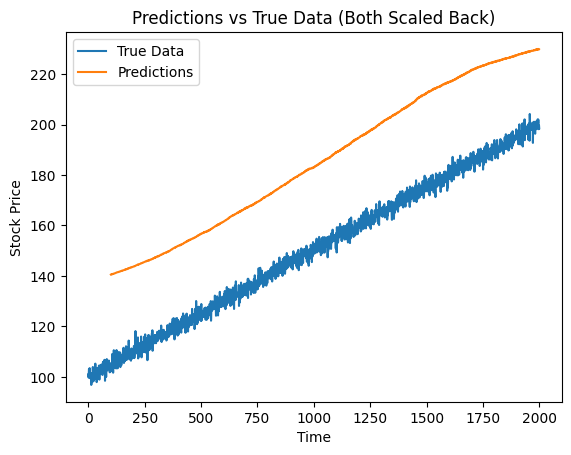

In [14]:

from sklearn.preprocessing import MinMaxScaler


# Make predictions
predictions = model.predict(X)
predictions = scalar.inverse_transform(predictions)

# Prepare true values for comparison
true_values = scalar.inverse_transform(data.reshape(-1, 1))

# Plot the predictions vs true values
import matplotlib.pyplot as plt

plt.plot(true_values, label='True Data')
plt.plot(np.arange(time_step, time_step + len(predictions)), predictions, label='Predictions')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.title('Predictions vs True Data (Both Scaled Back)')
plt.show()

In [11]:
## Write your code here.
from tensorflow.keras.layers import Dropout



# Add a dropout layer after the Flatten layer

flatten = tf.keras.layers.Flatten()(encoder_outputs)

dropout = Dropout(0.5)(flatten)

outputs = tf.keras.layers.Dense(1)(dropout)



# Build the model

model = tf.keras.Model(inputs, outputs)



# Compile the model

model.compile(optimizer='adam', loss='mse')



# Train the model

model.fit(X, Y, epochs=20, batch_size=32)



# Evaluate the model

loss = model.evaluate(X, Y)

print(f'Test loss: {loss}')

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - loss: 2.5656
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 995ms/step - loss: 1.0248
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - loss: 0.4716
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - loss: 0.2239
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - loss: 0.1151
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 994ms/step - loss: 0.0713
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - loss: 0.0532
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - loss: 0.0557  
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - loss: 0.0306
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 999ms/step - loss: 0.0269
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.0248
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - loss: 0.0252
Epoch 13/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 991ms/step - loss: 0.0228
Epoch 14/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 998ms/step - loss: 0.0185
Epoch 15/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0.0159
Ep

In [12]:
# Train the model with batch size 16
model.fit(X, Y, epochs=20, batch_size=16)

# Evaluate the model
loss = model.evaluate(X, Y)
print(f'Test loss with batch size 16: {loss}')

# Train the model with batch size 64
model.fit(X, Y, epochs=20, batch_size=64)

# Evaluate the model
loss = model.evaluate(X, Y)
print(f'Test loss with batch size 64: {loss}')

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 62s 525ms/step - loss: 0.0293
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 81s 512ms/step - loss: 0.0409
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 85s 540ms/step - loss: 0.0372
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 61s 517ms/step - loss: 0.0454
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 62s 524ms/step - loss: 0.0479
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 64s 537ms/step - loss: 0.0218
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 62s 524ms/step - loss: 0.0169
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 63s 525ms/step - loss: 0.0113
Epoch 9/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 63s 532ms/step - loss: 0.0105
Epoch 10/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 63s 529ms/step - loss: 0.0133
Epoch 11/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 82s 528ms/step - loss: 0.0124
Epoch 12/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 82s 522ms/step - loss: 0.0112
Epoch 13/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 62s 523ms/step - loss: 0.0076
Epoch 14/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 61s 513ms/step - loss: 0.0144
Epoch 15/20
119

In [13]:
# Change the activation function of the Dense layer to tanh
outputs = tf.keras.layers.Dense(1, activation='tanh')(flatten)

# Build the model
model = tf.keras.Model(inputs, outputs)

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X, Y, epochs=20, batch_size=32)

# Evaluate the model
loss = model.evaluate(X, Y)
print(f'Test loss with tanh activation: {loss}')

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - loss: 0.0490
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 59s 986ms/step - loss: 0.0086
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - loss: 0.0046
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 59s 991ms/step - loss: 0.0044
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - loss: 0.0031
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - loss: 0.0024
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 81s 992ms/step - loss: 0.0030
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 83s 999ms/step - loss: 0.0021
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 80s 980ms/step - loss: 0.0026
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - loss: 0.0025
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 59s 979ms/step - loss: 0.0024
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - loss: 0.0020
Epoch 13/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0018
Epoch 14/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 59s 982ms/step - loss: 0.0023
Epoch 15/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - loss: 0.002